<a href="https://colab.research.google.com/github/gauravjha201/Brain_Tumor_Adversarial_Robustness/blob/main/Stage_E_RetrainModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,classification_report


In [3]:
DATASET_PATH="/content/drive/MyDrive/Br35H"

train_dataset=tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224,224),
    batch_size=32,
    label_mode='binary',
    class_names=['no','yes']

)

val_dataset=tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224,224),
    batch_size=32,
    label_mode='binary',
    class_names=['no','yes']
)


train_dataset=train_dataset.map(
    lambda x,y:(x/255,tf.expand_dims(tf.cast(y,tf.float32),axis=1))
    )
val_dataset=val_dataset.map(
    lambda x,y:(x/255,tf.expand_dims(tf.cast(y,tf.float32),axis=1))
)

Found 3023 files belonging to 2 classes.
Using 2419 files for training.
Found 3023 files belonging to 2 classes.
Using 604 files for validation.


In [4]:
model=tf.keras.models.load_model("/content/drive/MyDrive/baseline_model.h5")

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
def fgsm_attack(model, images, labels, epsilon):
  labels=tf.squeeze(labels,axis=-1)

  with tf.GradientTape() as tape:
      tape.watch(images)
      predictions = model(images)
      loss = tf.keras.losses.binary_crossentropy(labels, predictions)

  gradient = tape.gradient(loss, images)
  adv_images=images+epsilon*tf.sign(gradient)

  return tf.clip_by_value(adv_images, 0, 1)

In [27]:
EPOCHS=10
epsilon=0.04
alpha=0.005
iterations=5

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    for images,labels in train_dataset:

        labels=tf.squeeze(labels,axis=-1)

        adv_images=images

        # Mini-PGD loop
        for i in range(iterations):
            with tf.GradientTape() as tape:
                tape.watch(adv_images)
                preds=model(adv_images)
                loss=tf.keras.losses.binary_crossentropy(labels, preds)

            grad=tape.gradient(loss, adv_images)

            adv_images=adv_images + alpha * tf.sign(grad)
            adv_images=tf.clip_by_value(adv_images,images-epsilon,images+epsilon)
            adv_images=tf.clip_by_value(adv_images,0,1)

        # Mixed training
        combined_images=tf.concat([images,adv_images],axis=0)
        combined_labels=tf.concat([labels,labels],axis=0)

        model.train_on_batch(combined_images,combined_labels)


Epoch 1/10

Epoch 2/10

Epoch 3/10

Epoch 4/10

Epoch 5/10

Epoch 6/10

Epoch 7/10

Epoch 8/10

Epoch 9/10

Epoch 10/10


In [28]:
model.save('/content/drive/MyDrive/adv_trained_model.h5')


In [29]:
clean_loss,clean_acc=model.evaluate(val_dataset)

print(f"Clean Accuracy After Defense: {clean_acc*100:.2f}%")

19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 122ms/step - accuracy: 0.8808 - loss: 0.6501
Clean Accuracy After Defense: 88.08%


In [30]:
fgsm_acc_list=[]

epsilon=0.04

for images,labels in val_dataset:
  adv_images=fgsm_attack(model,images,labels,epsilon)

  preds=model.predict(adv_images)
  preds=(preds>0.5).astype(int)

  labels_np=labels.numpy().astype(int)

  acc=np.mean(preds==labels_np)
  fgsm_acc_list.append(acc)

print(f"Average FGSM Accuracy After Defense: {np.mean(fgsm_acc_list)*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Average FGSM Accuracy After Defense: 48.91%


In [31]:
y_true=[]
y_pred=[]

for images,labels in val_dataset:
  preds=model.predict(images)
  preds=(preds>0.5).astype(int).flatten() # Flatten preds to 1D array

  # Convert labels to int and flatten to 1D array
  true_labels = labels.numpy().astype(int).flatten()
  y_true.extend(true_labels)
  y_pred.extend(preds)


print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
              precision    recall  f1-score   support

           0       0.82      0.98      0.89       298
           1       0.97      0.79      0.87       306

    accuracy                           0.88       604
   macro avg       0.89      0.88      0.88     

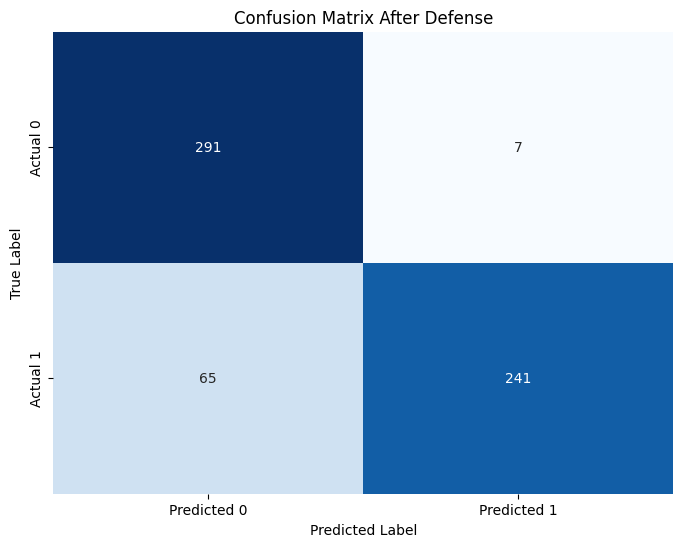

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

cm=confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix After Defense')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [33]:
clean_acc_before = 0.98
fgsm_acc_before = 0.70

print("\n===== FINAL COMPARISON ====")

print("Before Defense:")
print(f"Clean Accuracy: {clean_acc_before*100:.2f}%")
print(f"FGSM Accuracy: {fgsm_acc_before*100:.2f}%")

print("\nAfter Defense:")
print(f"Clean Accuracy: {clean_acc*100:.2f}%")
print(f"FGSM Accuracy: {np.mean(fgsm_acc_list)*100:.2f}%")


===== FINAL COMPARISON ====
Before Defense:
Clean Accuracy: 98.00%
FGSM Accuracy: 70.00%

After Defense:
Clean Accuracy: 88.08%
FGSM Accuracy: 48.91%


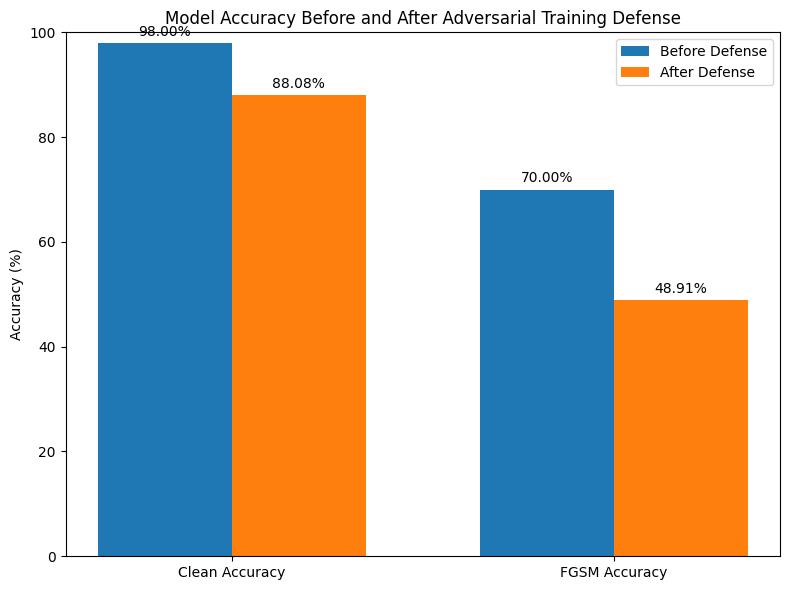

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# Data from the executed cells and prompt
clean_acc_before = 0.98
fgsm_acc_before = 0.70
clean_acc_after = clean_acc
fgsm_acc_after = np.mean(fgsm_acc_list)

labels = ['Clean Accuracy', 'FGSM Accuracy']
before_defense = [clean_acc_before, fgsm_acc_before]
after_defense = [clean_acc_after, fgsm_acc_after]

x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(8, 6))
rects1 = ax.bar(x - width/2, [val * 100 for val in before_defense], width, label='Before Defense')
rects2 = ax.bar(x + width/2, [val * 100 for val in after_defense], width, label='After Defense')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Accuracy (%)')
ax.set_title('Model Accuracy Before and After Adversarial Training Defense')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim(0, 100)

def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

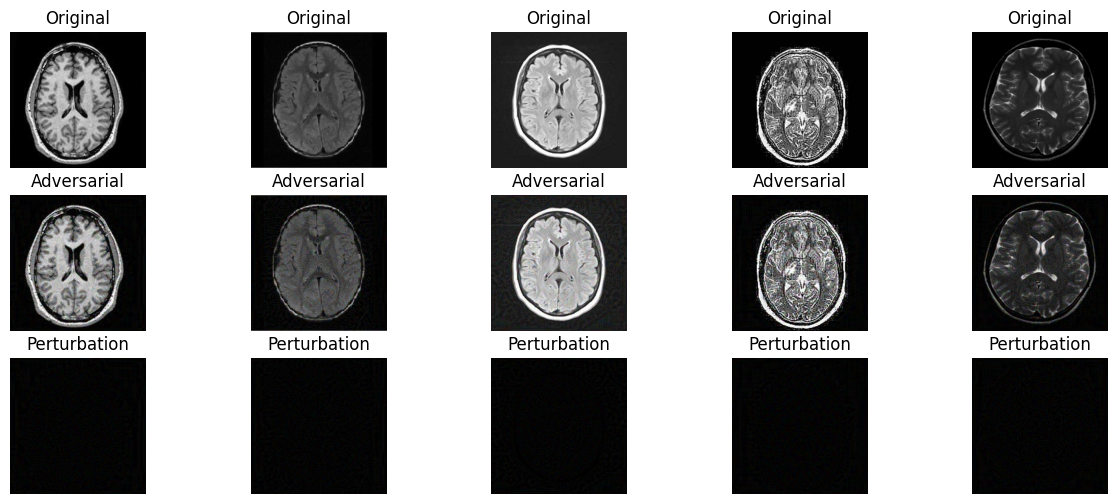

In [35]:
for images,labels in val_dataset.take(1):
    adv_images=fgsm_attack(model,images,labels,epsilon=0.03)

    plt.figure(figsize=(15,6))

    for i in range(5):
        # Original
        plt.subplot(3,5,i+1)
        plt.imshow(images[i])
        plt.title("Original")
        plt.axis('off')

        # Adversarial
        plt.subplot(3,5,i+6)
        plt.imshow(adv_images[i])
        plt.title("Adversarial")
        plt.axis('off')

        # Noise
        plt.subplot(3,5,i+11)
        plt.imshow(adv_images[i]-images[i])
        plt.title("Perturbation")
        plt.axis('off')

    plt.show()